In [10]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [11]:
# Load dataset
df = pd.read_csv("Best Songs on Spotify from 2000-2023.csv", sep=';')

# Display first rows
df.head()

,title,artist,top genre,year,bpm,energy,danceability,dB,liveness,valence,duration,acousticness,speechiness,popularity
0,Flowers,Miley Cyrus,pop,2023,118,68,71,-4,3,65,200,6,7,98
1,Cupid - Twin Ver.,FIFTY FIFTY,k-pop girl group,2023,120,59,78,-8,35,73,174,44,3,97
2,BESO,ROSALÍA,pop,2023,95,64,77,-7,17,53,195,74,14,96
3,Boy's a liar Pt. 2,PinkPantheress,bronx drill,2023,133,81,70,-8,25,86,131,25,5,96
4,Creepin' (with The Weeknd & 21 Savage),Metro Boomin,rap,2022,98,62,72,-6,8,17,222,42,5,96


In [12]:
# Dataset shape
print("Dataset shape:", df.shape)

# Column names
print(df.columns)

# Data types
df.info()

Dataset shape: (2385, 14)
Index(['title', 'artist', 'top genre', 'year', 'bpm', 'energy',
       'danceability ', 'dB', 'liveness', 'valence', 'duration',
       'acousticness', 'speechiness ', 'popularity'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2385 entries, 0 to 2384
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          2385 non-null   object
 1   artist         2385 non-null   object
 2   top genre      2385 non-null   object
 3   year           2385 non-null   int64 
 4   bpm            2385 non-null   int64 
 5   energy         2385 non-null   int64 
 6   danceability   2385 non-null   int64 
 7   dB             2385 non-null   int64 
 8   liveness       2385 non-null   int64 
 9   valence        2385 non-null   int64 
 10  duration       2385 non-null   int64 
 11  acousticness   2385 non-null   int64 
 12  speechiness    2385 non-null   int64 
 13  popularity  

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Rename columns for easier use
df.rename(columns={
    'top genre': 'genre',
    'dB': 'loudness'
}, inplace=True)

# Check missing values
print(df.isnull().sum())

# Fill missing values
df.fillna(0, inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

print("Clean dataset shape:", df.shape)

title           0
artist          0
genre           0
year            0
bpm             0
energy          0
danceability    0
loudness        0
liveness        0
valence         0
duration        0
acousticness    0
speechiness     0
popularity      0
dtype: int64
Clean dataset shape: (2385, 14)


In [15]:
numeric_cols = [
    'bpm','energy','danceability','loudness',
    'liveness','valence','duration',
    'acousticness','speechiness','popularity'
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)


In [16]:
print(df[numeric_cols].describe())

               bpm       energy  danceability     loudness     liveness  \
count  2385.000000  2385.000000   2385.000000  2385.000000  2385.000000   
mean    119.783648    69.792453     67.034801    -5.771488    17.787002   
std      27.273075    16.164609     13.719049     2.072153    13.629287   
min      60.000000     6.000000     18.000000   -18.000000     2.000000   
25%      98.000000    59.000000     59.000000    -7.000000     9.000000   
50%     120.000000    71.000000     68.000000    -5.000000    12.000000   
75%     134.000000    82.000000     77.000000    -4.000000    23.000000   
max     211.000000   100.000000     98.000000     0.000000    84.000000   

           valence     duration  acousticness  speechiness   popularity  
count  2385.000000  2385.000000   2385.000000  2385.000000  2385.000000  
mean     54.233962   225.946751     15.612998    10.112369    70.526625  
std      22.458084    43.226704     20.277746     9.520815    11.419740  
min       4.000000   115.000

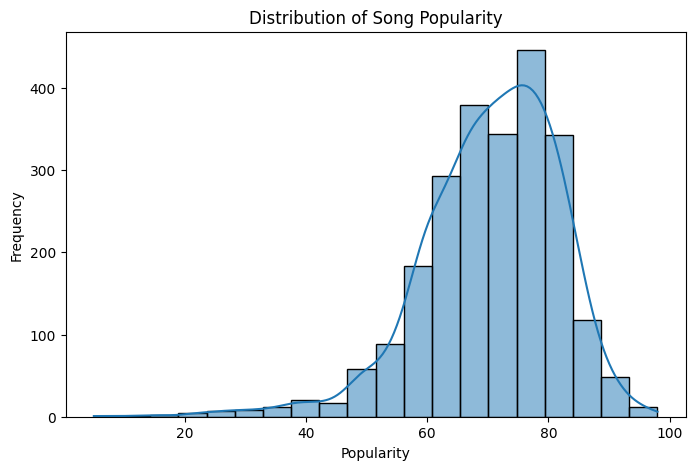

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['popularity'], bins=20, kde=True)

plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Frequency")
plt.show()

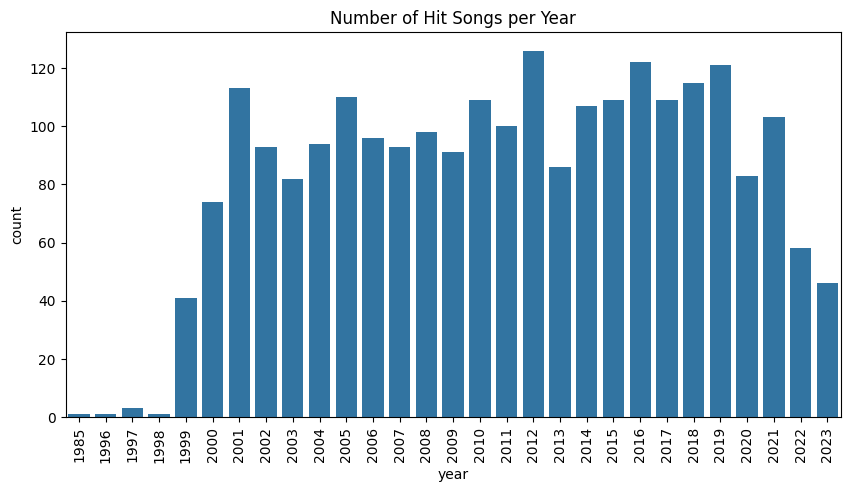

In [18]:
plt.figure(figsize=(10,5))
sns.countplot(x='year', data=df)

plt.xticks(rotation=90)
plt.title("Number of Hit Songs per Year")
plt.show()

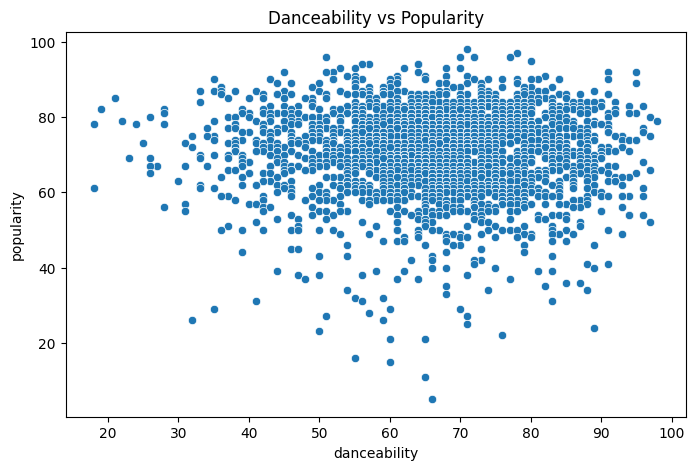

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='danceability', y='popularity', data=df)

plt.title("Danceability vs Popularity")
plt.show()

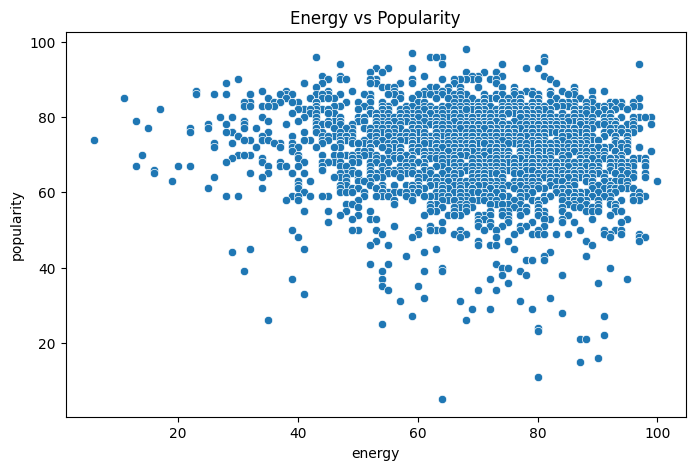

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='energy', y='popularity', data=df)

plt.title("Energy vs Popularity")
plt.show()

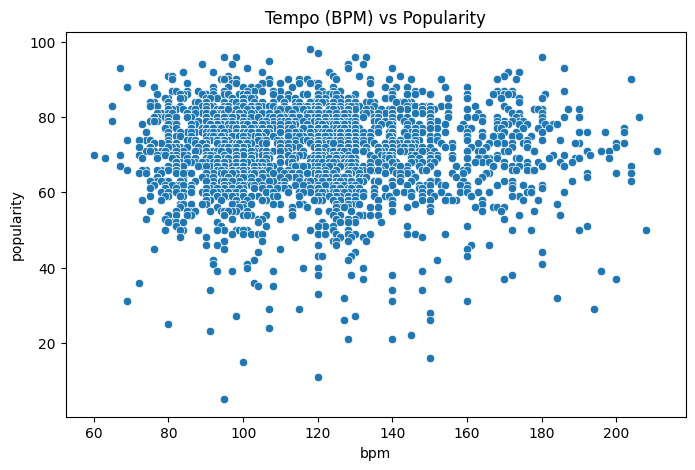

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='bpm', y='popularity', data=df)

plt.title("Tempo (BPM) vs Popularity")
plt.show()

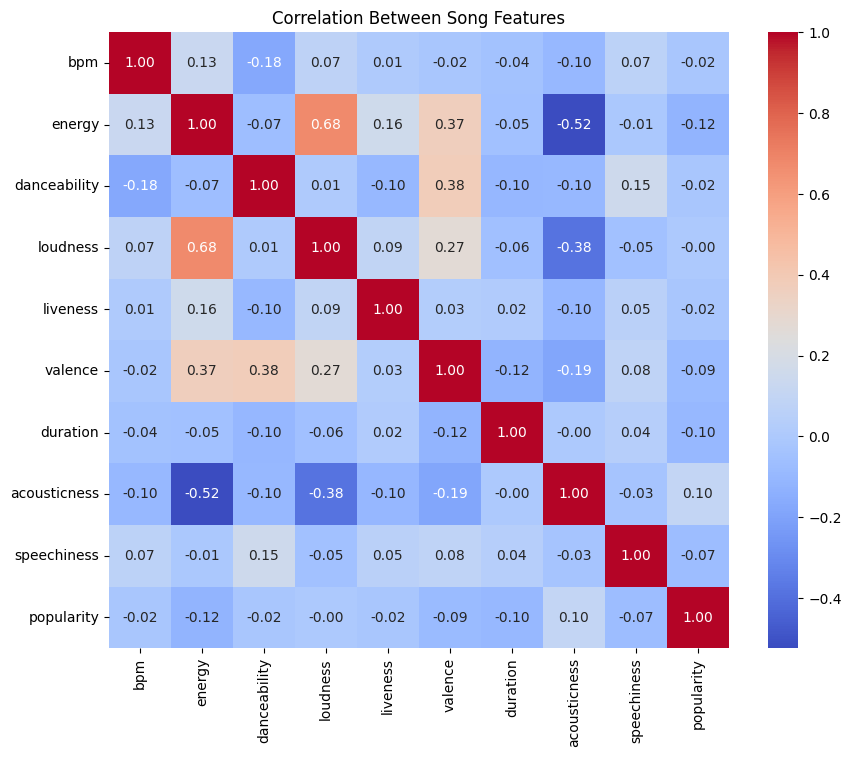

In [22]:
plt.figure(figsize=(10,8))

sns.heatmap(df[numeric_cols].corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Between Song Features")
plt.show()

In [23]:
X = df[['bpm','energy','danceability','loudness',
        'liveness','valence','duration',
        'acousticness','speechiness']]

y = df['popularity']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [25]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("MSE:", mean_squared_error(y_test, lr_pred))
print("R2 Score:", r2_score(y_test, lr_pred))

Linear Regression Results
MAE: 8.586528609001915
MSE: 123.09117023205154
R2 Score: 0.029965595217331886


In [26]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Results")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))
print("R2 Score:", r2_score(y_test, rf_pred))

Random Forest Results
MAE: 8.861818723951405
MSE: 129.74095418006291
R2 Score: -0.022438807160044316


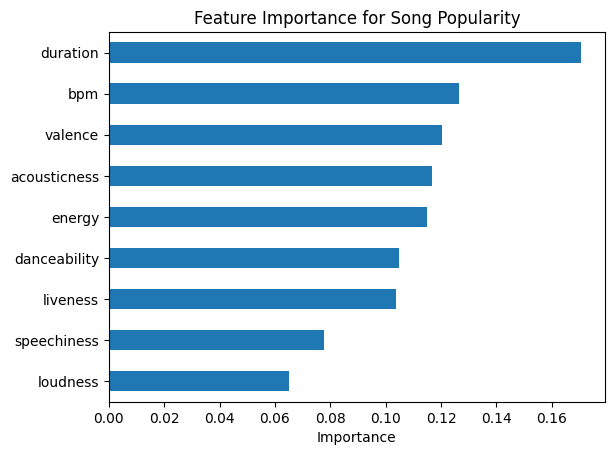

In [27]:
importance = rf_model.feature_importances_

feature_importance = pd.Series(importance, index=X.columns)

feature_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance for Song Popularity")
plt.xlabel("Importance")
plt.show()

In [28]:
top_songs = df.sort_values(by='popularity', ascending=False)

print(top_songs[['title','artist','year','popularity']].head(10))

                                    title          artist  year  popularity
0                                 Flowers     Miley Cyrus  2023          98
1                       Cupid - Twin Ver.     FIFTY FIFTY  2023          97
3                      Boy's a liar Pt. 2  PinkPantheress  2023          96
5                                Daylight   David Kushner  2023          96
2                                    BESO         ROSALÍA  2023          96
4  Creepin' (with The Weeknd & 21 Savage)    Metro Boomin  2022          96
6                                     TQG         KAROL G  2023          96
7           Calm Down (with Selena Gomez)            Rema  2022          95
8                               Anti-Hero    Taylor Swift  2022          94
9                            Here With Me            d4vd  2022          94


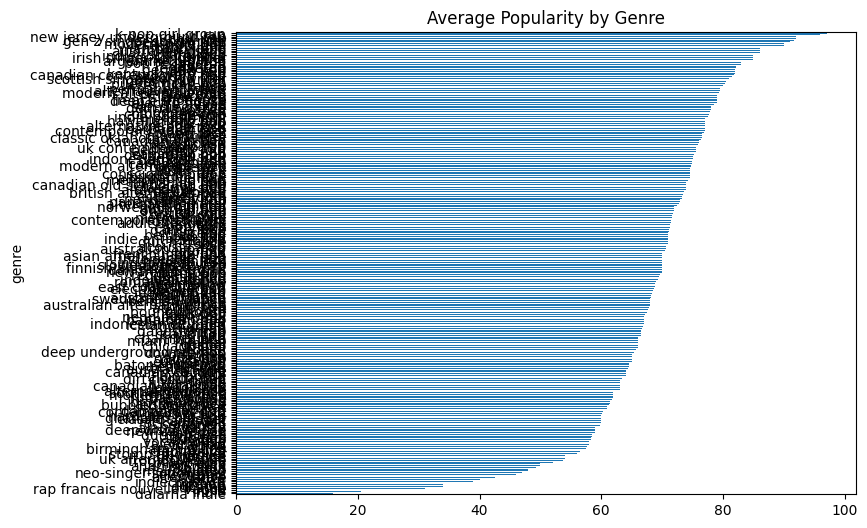

In [29]:
genre_popularity = df.groupby('genre')['popularity'].mean().sort_values()

genre_popularity.plot(kind='barh', figsize=(8,6))

plt.title("Average Popularity by Genre")
plt.show()

In [30]:
print("Key Insights:")
print("1. Songs with high danceability and energy tend to have higher popularity.")
print("2. Loudness and tempo also influence hit songs.")
print("3. Emotional positivity (valence) contributes to song success.")

Key Insights:
1. Songs with high danceability and energy tend to have higher popularity.
2. Loudness and tempo also influence hit songs.
3. Emotional positivity (valence) contributes to song success.
